In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
from Files import Model
from Files import NEGM
from Files import HelperFunctions
import matplotlib.pyplot as plt


In [2]:
model = Model.DurableBufferStock()
model.modelSetup()
model.createGrids()
model.solve()
model.simulate()
model.simulate2()

par = model.par
sol = model.sol
sim = model.sim
sim2 = model.sim2

Number of gridpoints: t = 10 p = 10 n = 30 m = 30
8
7
6
5
4
3
2
1
0
Solver time: 108.12 seconds
Simulation time: 1.47 seconds
Simulation time: 0.66 seconds


In [3]:
#print("n = ", par.grid_n[5,49].round(3), "m = ",par.grid_m[5,59].round(3))
#for p in range(20):
 #   u = HelperFunctions.utility(sol.c[5,p,49,59], sol.d[5,p,49,59], par)
  #  print("p =",par.grid_p[5,p].round(3), "d =" ,sol.d[5,p,49,59].round(3), "c =", sol.c[5,p,49,59].round(3), "u =", u.round(3))

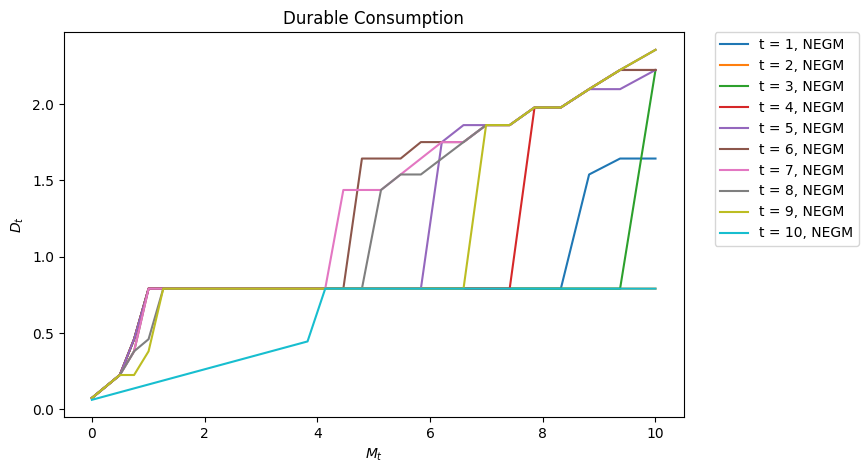

In [4]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):
    ax.plot(sol.m[t, 5, 10, :],sol.d[t, 5, 10, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$D_t$")
ax.set_title(f'Durable Consumption')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

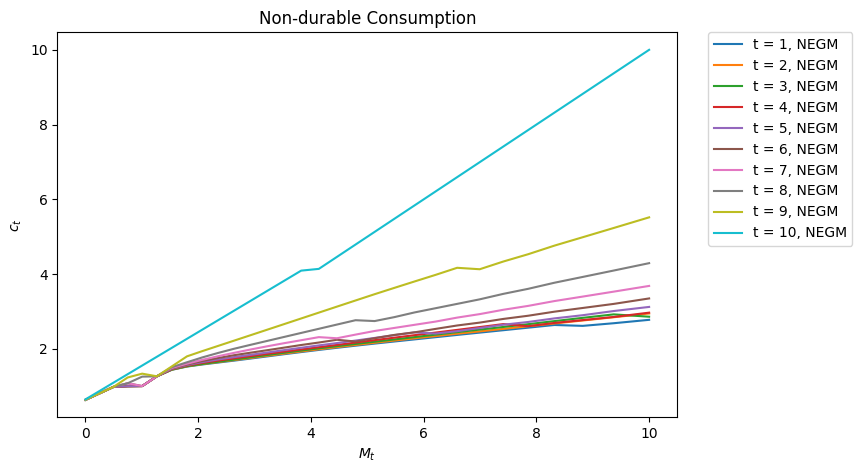

In [5]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):
    ax.plot(sol.m[t, 5, 10, :],sol.c[t, 5, 10, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$c_t$")
ax.set_title(f'Non-durable Consumption')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

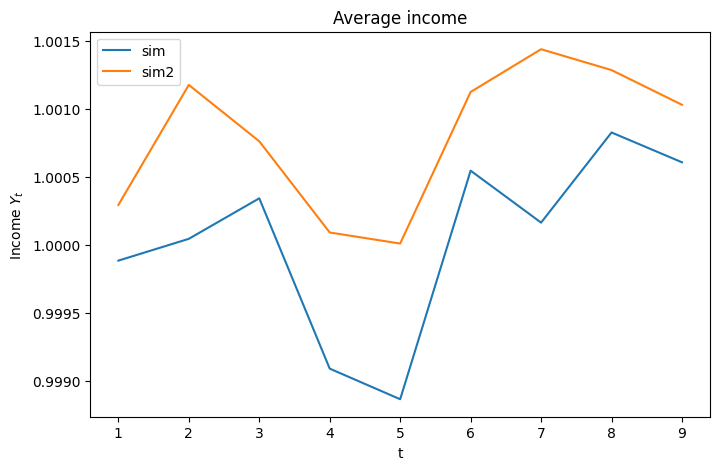

In [9]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.y, axis=1), label='sim')
ax.plot(np.arange(par.T), np.mean(sim2.y, axis=1), label='sim2')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Income $Y_t$")
ax.set_title(f'Average income')
ax.legend()
plt.show()

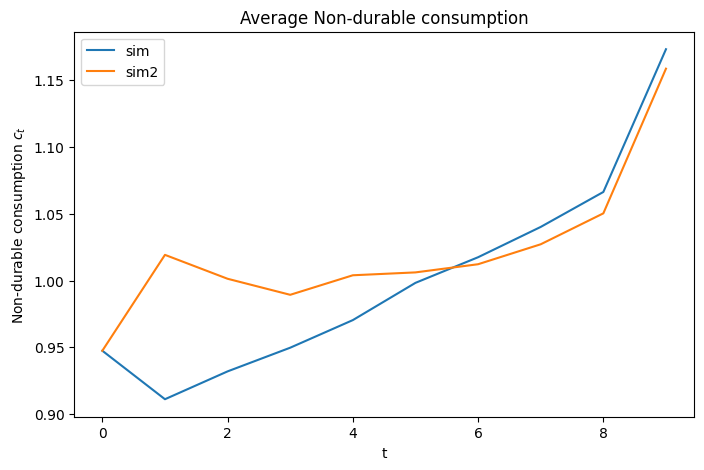

In [10]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.c, axis=1), label='sim')
ax.plot(np.arange(par.T), np.mean(sim2.c, axis=1), label='sim2')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Non-durable consumption $c_t$")
ax.set_title(f'Average Non-durable consumption')
ax.legend()
plt.show()

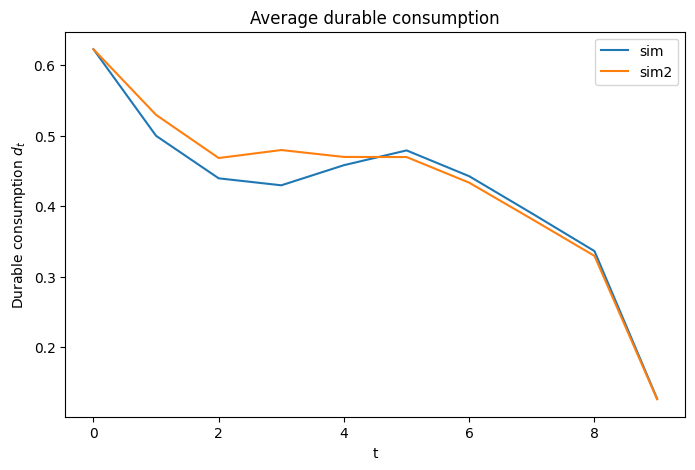

In [11]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.d, axis=1), label='sim')
ax.plot(np.arange(par.T), np.mean(sim2.d, axis=1), label='sim2')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Durable consumption $d_t$")
ax.set_title(f'Average durable consumption')
ax.legend()
plt.show()